# Build a F200W and F090W image from nirspec IFU data

Since the F200W and F090 filter images of sombrero are saturated in the very center we need to do something to get a light profile of the very center of the galaxy. The idea here is to use the NIRSPEC/IFU data combined with the response function of the F200 and F090 filters to construct a non saturated image in the very center and interpolate it to make a joint continuous image without saturation. 

Lets just inspect the IFU data first

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table


## Load and inspect cube

In [2]:
nirspec_ifu = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/sombrero_nirspec_1113_p1110_g235h_s3d.fits')

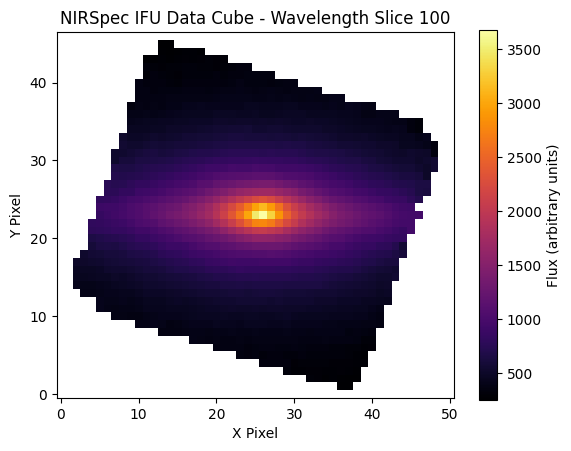

In [3]:
# lets start by visualizing the data cube with a simple wavelength slice
nirspec_ifu[1].data.shape  # (n_wave, n_y, n_x)

# plot the central wavelength slice
plt.imshow(nirspec_ifu[1].data[500, :, :], origin='lower', cmap='inferno')
plt.colorbar(label='Flux (arbitrary units)')
plt.title('NIRSpec IFU Data Cube - Wavelength Slice 100')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()

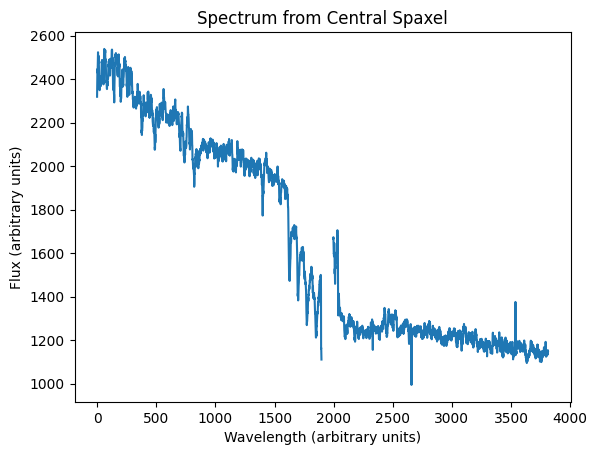

In [4]:
# plot a spectrum from the central spaxel
central_spectrum = nirspec_ifu[1].data[:, 25,25]  # (n_wave,)
plt.plot(central_spectrum)
plt.title('Spectrum from Central Spaxel')
plt.xlabel('Wavelength (arbitrary units)')
plt.ylabel('Flux (arbitrary units)')
plt.show()

In [5]:
# convert the spectrum wavelenght to microns using the header information
def wavelength_from_header(header, n_wave):
    wavstart = header['WAVSTART']  # starting wavelength in microns
    wavend = header['WAVEND']  # ending wavelength in microns
    waveinc = (wavend - wavstart) / (n_wave - 1)  # wavelength increment per pixel

    return wavstart + np.arange(n_wave) * waveinc

def wavelength_in_microns(ifu_hdu):
    header = ifu_hdu[1].header
    n_wave = ifu_hdu[1].data.shape[0]
    return wavelength_from_header(header, n_wave)*1e6

wavelengths_microns = wavelength_in_microns(nirspec_ifu) 

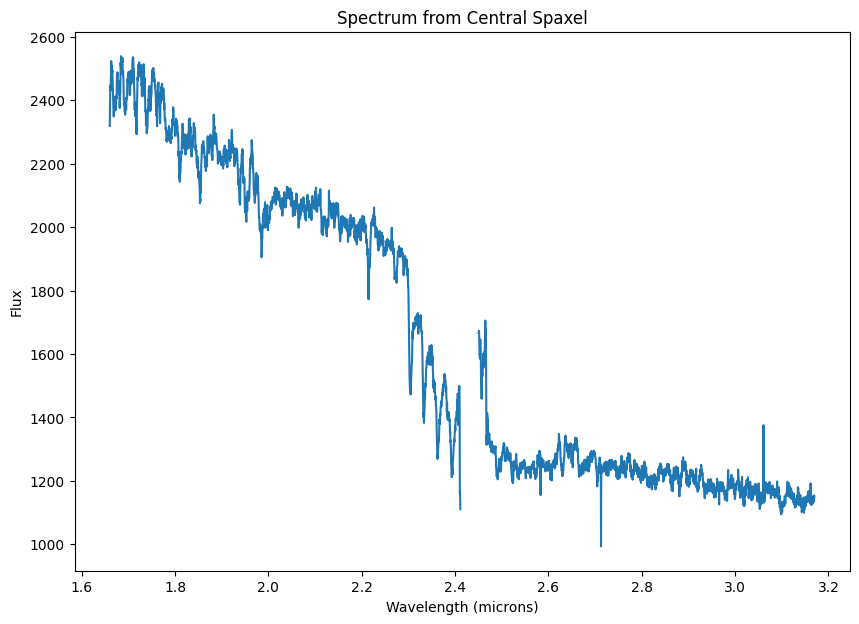

In [6]:
# plot the spectrum with wavelength in microns
fig, ax = plt.subplots(figsize=(10,7))
ax.plot(wavelengths_microns, central_spectrum)
ax.set_title('Spectrum from Central Spaxel')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Flux')
plt.show()

# Load and inspect throughput functions

In [7]:
system_throughput_f200 = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/nircam_throughputs/mean_throughputs/F200W_May2024_mean_system_throughput.txt', format='ascii')
system_throughput_f090 = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/nircam_throughputs/mean_throughputs/F090W_May2024_mean_system_throughput.txt', format='ascii')

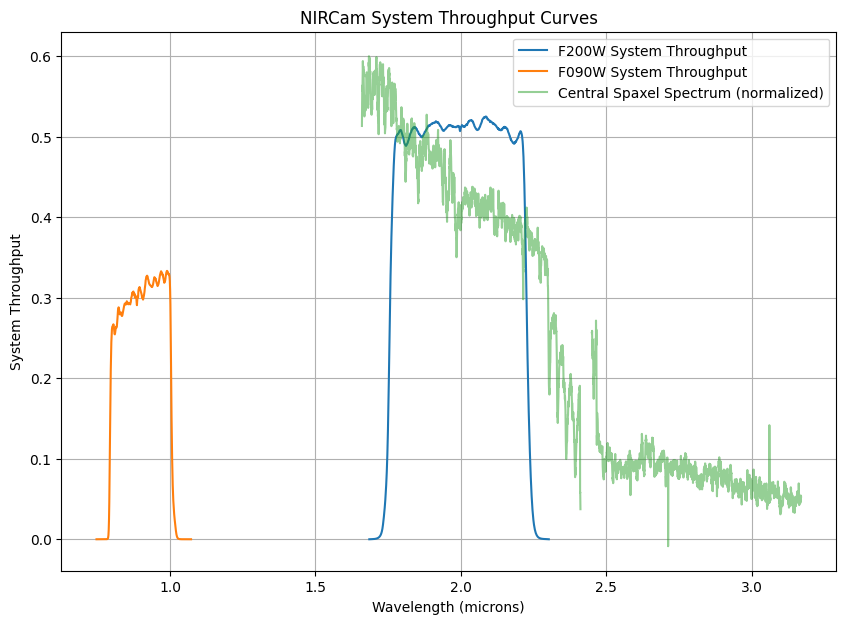

In [8]:
# plot the throughput curve
fig, ax = plt.subplots(figsize=(10,7))
# thoughput curves are already in microns, so we can plot directly
ax.plot(system_throughput_f200['Microns'], system_throughput_f200['Throughput'], label='F200W System Throughput')
ax.plot(system_throughput_f090['Microns'], system_throughput_f090['Throughput'], label='F090W System Throughput')
# spectrum of a random pixel
ax.plot(wavelengths_microns, central_spectrum / np.nanmax(central_spectrum) - 0.4, label='Central Spaxel Spectrum (normalized)', alpha=0.5)

ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('System Throughput')
ax.set_title('NIRCam System Throughput Curves')
ax.legend()
ax.grid(True)
plt.show()

In [9]:
# convert the spectrum wavelenght to microns using the header information
def wavelength_from_header(header, n_wave):
    wavstart = header['WAVSTART']  # starting wavelength in microns
    wavend = header['WAVEND']  # ending wavelength in microns
    waveinc = (wavend - wavstart) / (n_wave - 1)  # wavelength increment per pixel

    return wavstart + np.arange(n_wave) * waveinc

def wavelength_in_microns(ifu_hdu):
    header = ifu_hdu[1].header
    n_wave = ifu_hdu[1].data.shape[0]
    return wavelength_from_header(header, n_wave)*1e6

def build_throughput_interp(system_throughput_table):
    from scipy.interpolate import interp1d
    return interp1d(system_throughput_table['Microns'], system_throughput_table['Throughput'], bounds_error=False, fill_value=0.0)

def photometry_from_ifu(ifu_cube, system_thoughput, verbose = False):
    
    # build interpolator from ascii table of throughput
    throughput_interp = build_throughput_interp(system_thoughput)
    # ifu_cube shape: (n_wave, n_y, n_x)
    n_wave, n_y, n_x = ifu_cube[1].shape
    photometry = np.zeros((n_y, n_x))
    wavelength_microns = wavelength_in_microns(ifu_cube) 
    for i in range(n_wave):
        if verbose:
            print(f'Processing wavelength slice {i+1}/{n_wave} (wavelength = {wavelength_microns[i]:.2f} microns)')
            print(f'  Throughput at this wavelength: {throughput_interp(wavelength_microns[i]):.4f}')
        weighted_slice = ifu_cube[1].data[i, :, :] * throughput_interp(wavelength_microns[i])
        # replace NaNs in the slice with 0s
        nan_mask = np.isnan(weighted_slice)
        if np.any(nan_mask):
            if verbose:
                print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
            weighted_slice[nan_mask] = 0.0
        photometry += weighted_slice

    
    return photometry

In [10]:
f200w_photometry = photometry_from_ifu(nirspec_ifu, system_throughput_f200)

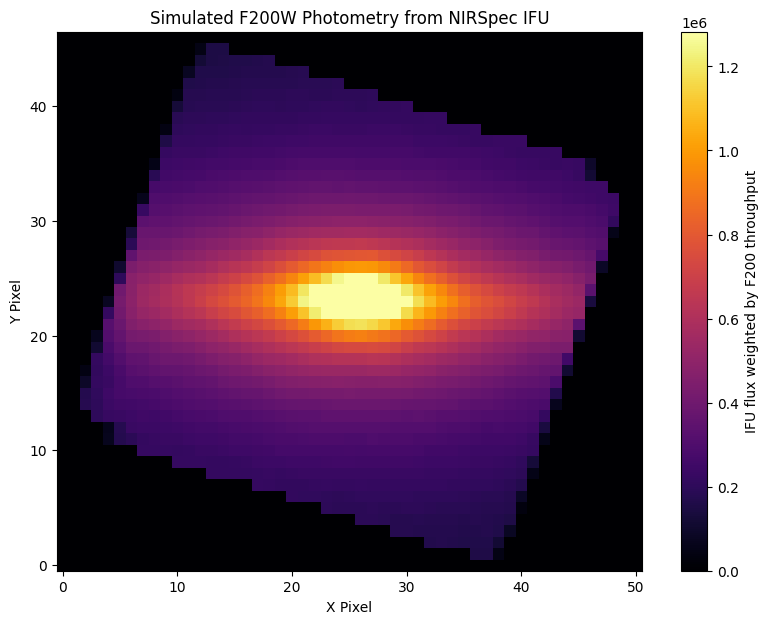

In [11]:
# plot the photometry image
fig, ax = plt.subplots(figsize=(10,7))
im = ax.imshow(f200w_photometry, origin='lower', cmap='inferno',
 vmin=0, vmax=np.nanpercentile(f200w_photometry, 99))
ax.set_title('Simulated F200W Photometry from NIRSpec IFU')
ax.set_xlabel('X Pixel')
ax.set_ylabel('Y Pixel')
fig.colorbar(im, label='IFU flux weighted by F200 throughput')
plt.show()

In [12]:
# make pixels that are 0 in the photometry image NaNs so that they don't affect the reprojection
f200w_photometry[f200w_photometry == 0] = np.nan

# Manage flux units

The spectrum comes in units of MJy/sr, so now I need to get both the F200W image and this IFU constructed one in the same units so that I can mix them up

In [13]:
# lets see the F200W header information to see if we can convert the photometry to physical units
f200_mosaic = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mosaics/f200_mosaic.fits')
# since the mosaic file does not have a lot of info we will check the i2d file for the mosaic to see if it has more info on the photometric calibration
#f200_i2d = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/f090_f200/jw06565-o002_t001_nircam_clear-f200w/jw06565-o002_t001_nircam_clear-f200w_i2d.fits')

Looks like both are in MJy/sr the big difference is that an IFU pixel is not the same size as the F200 image pixels

In [14]:
import numpy as np

def f200w_bandpass_average_from_ifu(nirspec_ifu, throughput_table, photon_weighted=True):
    hdr = nirspec_ifu[1].header
    cube = nirspec_ifu[1].data  # (nwave, ny, nx)

    nwave = cube.shape[0]
    wavstart = hdr["WAVSTART"]
    wavend   = hdr["WAVEND"]
    wave = wavstart + np.arange(nwave) * ((wavend - wavstart) / (nwave - 1))

    # Convert to microns if header is in meters (common)
    cunit3 = str(hdr.get("CUNIT3", "")).lower()
    if cunit3 in ["m", "meter", "meters"] or np.nanmedian(wave) < 1e-3:
        wave_um = wave * 1e6
    else:
        wave_um = wave

    # throughput sampled at cube wavelengths
    T = np.interp(wave_um,
                  throughput_table["Microns"], throughput_table["Throughput"],
                  left=0.0, right=0.0)

    # photon-weighted response (often appropriate): R ~ T * λ
    R = T * wave_um if photon_weighted else T

    cube0 = np.nan_to_num(cube, nan=0.0)

    num = np.trapz(cube0 * R[:, None, None], wave_um, axis=0)
    den = np.trapz(R, wave_um)

    return num / den   # same units as cube slices (MJy/sr)

f200w_from_ifu = f200w_bandpass_average_from_ifu(nirspec_ifu, system_throughput_f200)
# make the zeros nan so they don't affect the reprojection
f200w_from_ifu[f200w_from_ifu == 0] = np.nan


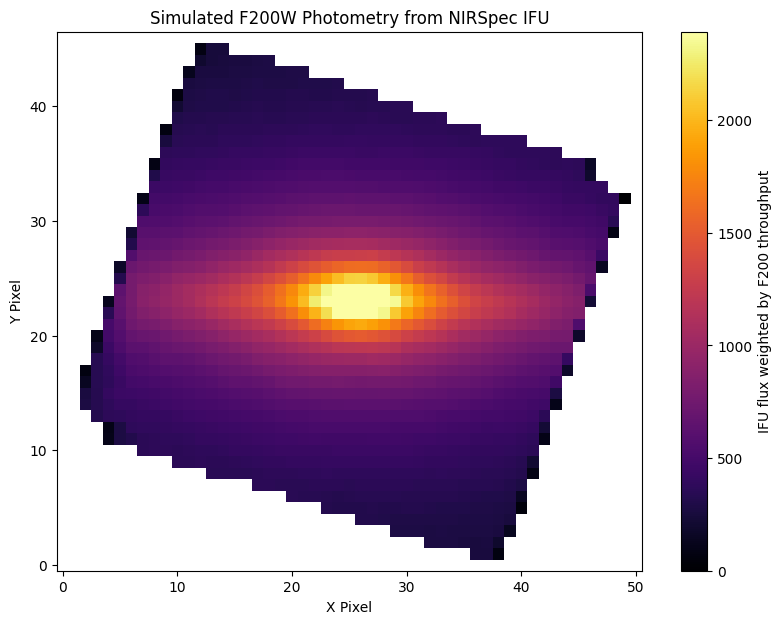

In [15]:
# plot the new image
# plot the photometry image
fig, ax = plt.subplots(figsize=(10,7))
im = ax.imshow(f200w_from_ifu, origin='lower', cmap='inferno',
 vmin=0, vmax=np.nanpercentile(f200w_from_ifu, 99))
ax.set_title('Simulated F200W Photometry from NIRSpec IFU')
ax.set_xlabel('X Pixel')
ax.set_ylabel('Y Pixel')
fig.colorbar(im, label='IFU flux weighted by F200 throughput')
plt.show()

In [16]:
print("IFU BUNIT:", nirspec_ifu[1].header.get("BUNIT"))
print("Mosaic BUNIT:", f200_mosaic[0].header.get("BUNIT"))

IFU BUNIT: MJy/sr
Mosaic BUNIT: None


# Mask the edge of the IFU data

In [17]:
import numpy as np
from scipy.ndimage import binary_erosion

def erode_valid_region_to_nan(img, n=5, structure=None):
    valid = np.isfinite(img)
    # Erode valid region by n pixels
    eroded = valid.copy()
    for _ in range(n):
        eroded = binary_erosion(eroded, structure=structure, border_value=0)
    out = img.copy()
    out[~eroded] = np.nan
    return out

f200w_from_ifu_masked = erode_valid_region_to_nan(f200w_from_ifu, n=1)

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_46420/1563711673.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


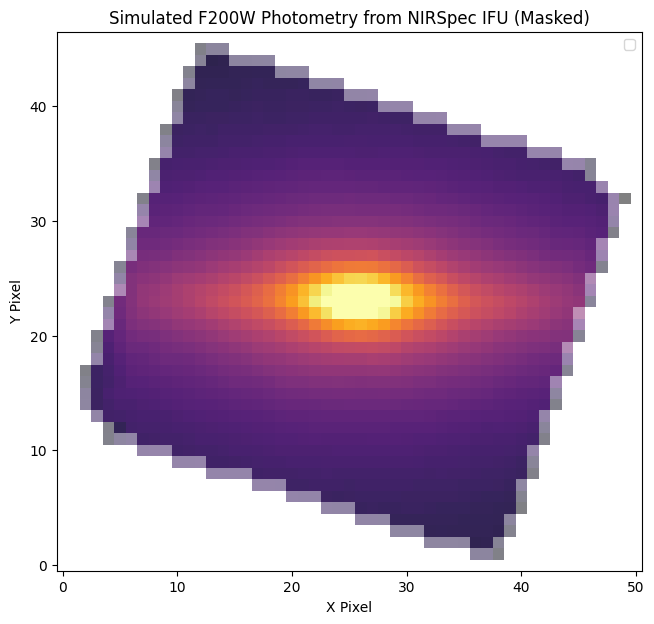

In [18]:
# plot the masked on top of the original
fig, ax = plt.subplots(figsize=(10,7))
im = ax.imshow(f200w_from_ifu, origin='lower', cmap='inferno',
 vmin=0, vmax=np.nanpercentile(f200w_from_ifu, 99), alpha=0.5, label='Original')
im_masked = ax.imshow(f200w_from_ifu_masked, origin='lower', cmap='inferno',
 vmin=0, vmax=np.nanpercentile(f200w_from_ifu, 99), alpha=0.8, label='Masked')
ax.set_title('Simulated F200W Photometry from NIRSpec IFU (Masked)')
ax.set_xlabel('X Pixel')
ax.set_ylabel('Y Pixel')
ax.legend()
plt.show()

# Reproject and interpolate the IFU constructed image into the f200 frame

In [19]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from reproject.mosaicking import reproject_and_coadd
from reproject import reproject_interp, reproject_exact

# build a clean 2D WCS from the IFU cube header
wcs3d = WCS(nirspec_ifu[1].header)

# This keeps only the celestial axes (ra, dec) and drops wavelength
wcs2d = wcs3d.celestial

# Make a fresh 2D FITS header from the 2D WCS
hdr2d = wcs2d.to_header(relax=True) 

# carry over useful metadata but I am not sure yet what is useful for the photometry image, so I will just carry over a few keywords that seem relevant to the flux calibration
for k in ["BUNIT", "PHOTMJSR", "PIXAR_SR"]:
    if k in nirspec_ifu[1].header:
        hdr2d[k] = nirspec_ifu[1].header[k]

# Create an HDU for the collapsed IFU photometric image
f200_img_hdu = fits.ImageHDU(data=f200w_from_ifu, header=hdr2d, name="IFU_F200W")
f200_img_hdu.writeto('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200_from_ifu_3.fits', overwrite=True)

# reference output WCS/shape from the F200W mosaic
shape_out = f200_mosaic[0].data.shape
wcs_out = WCS(f200_mosaic[0].header)

# Reproject + coadd
coadd, footprint = reproject_and_coadd(
    [f200_mosaic[0], f200_img_hdu],
    output_projection=wcs_out,
    shape_out=shape_out,
    reproject_function=reproject_exact, 
)

Set DATE-AVG to '2023-07-07T01:06:26.352' from MJD-AVG.
Set DATE-END to '2023-07-07T01:16:13.256' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -38.040306 from OBSGEO-[XYZ].
Set OBSGEO-H to 1744349933.102 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/venvs/hat/lib/python3.9/site-packages/reproject/spherical_intersect/core.py:35: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
from astropy.io import fits
import numpy as np

# coadd, footprint came from reproject_and_coadd(...)
# wcs_out is your output WCS (WCS(f200_mosaic[0].header))

hdr_out = wcs_out.to_header(relax=True)

# (optional) carry over some useful keywords from the reference mosaic
ref_hdr = f200_mosaic[0].header
for k in ["BUNIT", "PHOTMJSR", "PIXAR_SR", "FILTER", "INSTRUME", "TELESCOP"]:
    if k in ref_hdr and k not in hdr_out:
        hdr_out[k] = ref_hdr[k]

# Primary HDU: the coadded image
hdu0 = fits.PrimaryHDU(data=np.asarray(coadd, dtype=np.float32), header=hdr_out)

# Extension: footprint (0..1 coverage/weights)
hdu1 = fits.ImageHDU(data=np.asarray(footprint, dtype=np.float32), name="FOOTPRINT")

hdul = fits.HDUList([hdu0, hdu1])
hdul.writeto("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_exact.fits", overwrite=True)

In [ ]:
# save the new coadded image with the same header as the mosaic but with the data from the reprojected photometry image
coadd_hdu = fits.PrimaryHDU(data=coadd, header=f200_mosaic[0].header)
coadd_hdu.writeto('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200_from_ifu_reprojected.fits', overwrite=True)



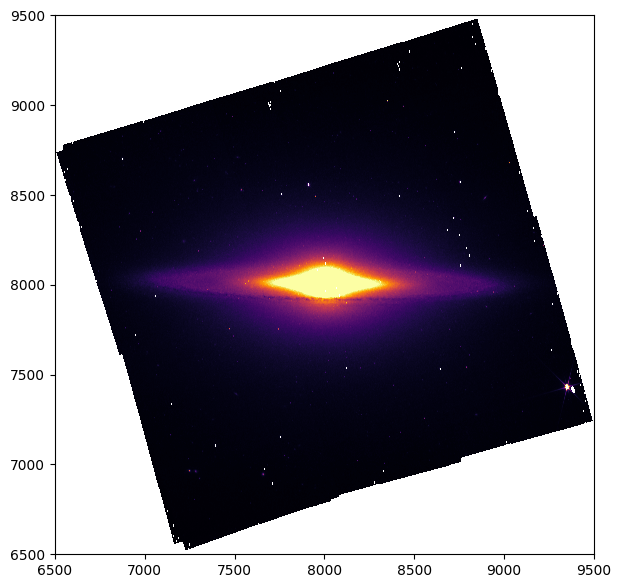

In [102]:
# plot the new image zoomed into the central region
fig, ax = plt.subplots(figsize=(10,7))
im = ax.imshow(coadd, origin='lower', cmap='inferno',
    vmin=0, vmax=np.nanpercentile(coadd, 99), 
    extent=(6500, 9500, 6500, 9500),
)
# zoom into the central region based on the WCS coordinates of the mosaic


plt.show()

# Coadd with eroded image

In [20]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from reproject.mosaicking import reproject_and_coadd
from reproject import reproject_interp

# build a clean 2D WCS from the IFU cube header
wcs3d = WCS(nirspec_ifu[1].header)

# This keeps only the celestial axes (ra, dec) and drops wavelength
wcs2d = wcs3d.celestial

# Make a fresh 2D FITS header from the 2D WCS
hdr2d = wcs2d.to_header(relax=True) 

# carry over useful metadata but I am not sure yet what is useful for the photometry image, so I will just carry over a few keywords that seem relevant to the flux calibration
for k in ["BUNIT", "PHOTMJSR", "PIXAR_SR"]:
    if k in nirspec_ifu[1].header:
        hdr2d[k] = nirspec_ifu[1].header[k]

# Create an HDU for the collapsed IFU photometric image
f200_img_hdu = fits.ImageHDU(data=f200w_from_ifu_masked, header=hdr2d, name="IFU_F200W")
#f200_img_hdu.writeto('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200_from_ifu_masked.fits', overwrite=True)

# reference output WCS/shape from the F200W mosaic
shape_out = f200_mosaic[0].data.shape
wcs_out = WCS(f200_mosaic[0].header)

# Reproject + coadd
coadd, footprint = reproject_and_coadd(
    [f200_mosaic[0], f200_img_hdu],
    output_projection=wcs_out,
    shape_out=shape_out,
    reproject_function=reproject_exact, 
)

Set DATE-AVG to '2023-07-07T01:06:26.352' from MJD-AVG.
Set DATE-END to '2023-07-07T01:16:13.256' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -38.040306 from OBSGEO-[XYZ].
Set OBSGEO-H to 1744349933.102 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/venvs/hat/lib/python3.9/site-packages/reproject/spherical_intersect/core.py:35: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  warnings.warn(
Set OBSGEO-B to   -38.040306 from OBSGEO-[XYZ].
Set OBSGEO-H to 1744349933.102 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/venvs/hat/lib/python3.9/site-packages/reproject/spherical_intersect/core.py:35: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  warnings.warn(


In [21]:


hdr_out = wcs_out.to_header(relax=True)

# (optional) carry over some useful keywords from the reference mosaic
ref_hdr = f200_mosaic[0].header
for k in ["BUNIT", "PHOTMJSR", "PIXAR_SR", "FILTER", "INSTRUME", "TELESCOP"]:
    if k in ref_hdr and k not in hdr_out:
        hdr_out[k] = ref_hdr[k]

# Primary HDU: the coadded image
hdu0 = fits.PrimaryHDU(data=np.asarray(coadd, dtype=np.float32), header=hdr_out)

# Extension: footprint (0..1 coverage/weights)
hdu1 = fits.ImageHDU(data=np.asarray(footprint, dtype=np.float32), name="FOOTPRINT")

hdul = fits.HDUList([hdu0, hdu1])
hdul.writeto("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked_exact.fits", overwrite=True)